In [1]:
1+1

2

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification, fetch_20newsgroups

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", None)

In [3]:
X, y = make_classification(
    n_samples=3000, n_features=6, n_informative=3, n_redundant=1,
    n_repeated=0, n_clusters_per_class=2, weights=[0.65, 0.35],
    flip_y=0.02, class_sep=1.1, random_state=SEED,
)

# Map generated columns -> realistic feature names.
# Cols 0,1 = strongest informative -> test_pass_rate, lint_error_count
# Col 2 = informative -> documentation_score
# Col 3 = redundant -> cyclomatic_complexity (correlated w/ informative signal)
# Cols 4,5 = noise -> execution_time_ms, memory_usage_mb
cols = ["test_pass_rate", "lint_error_count", "documentation_score",
        "cyclomatic_complexity", "execution_time_ms", "memory_usage_mb"]
grading_df = pd.DataFrame(X, columns=cols)

# Rescale to realistic ranges
grading_df["test_pass_rate"] = (grading_df["test_pass_rate"] - grading_df["test_pass_rate"].min()) / \
    (grading_df["test_pass_rate"].max() - grading_df["test_pass_rate"].min())
grading_df["lint_error_count"] = (grading_df["lint_error_count"].rank(pct=True) * 30).round().astype(int)
grading_df["documentation_score"] = (grading_df["documentation_score"] - grading_df["documentation_score"].min()) / \
    (grading_df["documentation_score"].max() - grading_df["documentation_score"].min())
grading_df["cyclomatic_complexity"] = (grading_df["cyclomatic_complexity"].rank(pct=True) * 45 + 1).round().astype(int)
grading_df["execution_time_ms"] = (grading_df["execution_time_ms"].rank(pct=True) * 5000).round().astype(int)
grading_df["memory_usage_mb"] = (grading_df["memory_usage_mb"].rank(pct=True) * 512).round().astype(int)
grading_df["quality_label"] = y  # 0 = needs revision, 1 = good submission

grading_df.head()

,test_pass_rate,lint_error_count,documentation_score,cyclomatic_complexity,execution_time_ms,memory_usage_mb,quality_label
0,0.477709,25,0.545361,14,3955,327,1
1,0.451009,1,0.610536,25,4295,469,0
2,0.185283,19,0.656763,37,35,8,0
3,0.686481,16,0.363560,14,4975,509,1
4,0.430342,11,0.568778,20,3565,312,0


In [4]:
print("Shape:", grading_df.shape)
print("\nClass balance:\n", grading_df["quality_label"].value_counts(normalize=True))
print("\nMissingness:\n", grading_df.isna().sum())
grading_df.describe().T

Shape: (3000, 7)

Class balance:
 quality_label
0    0.648
1    0.352
Name: proportion, dtype: float64

Missingness:
 test_pass_rate           0
lint_error_count         0
documentation_score      0
cyclomatic_complexity    0
execution_time_ms        0
memory_usage_mb          0
quality_label            0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
test_pass_rate,3000.0,0.386079,0.133934,0.0,0.301528,0.366412,0.454878,1.0
lint_error_count,3000.0,15.005000,8.671603,0.0,8.000000,15.000000,22.250000,30.0
documentation_score,3000.0,0.549673,0.133611,0.0,0.460296,0.550265,0.637960,1.0
cyclomatic_complexity,3000.0,23.507333,12.999087,1.0,12.000000,24.000000,35.000000,46.0
execution_time_ms,3000.0,2500.833333,1443.616113,2.0,1251.500000,2501.000000,3750.500000,5000.0
memory_usage_mb,3000.0,256.085333,147.825743,0.0,128.000000,256.000000,384.000000,512.0
quality_label,3000.0,0.352000,0.477674,0.0,0.000000,0.000000,1.000000,1.0


In [14]:
pip install datasets

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
  Using cached filelock-3.32.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached multiprocess-0.70.19-py310-none-any.whl.metadata (7.5 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached huggingface_hub-1.26.0-py3-none-any.whl.metadata (16 kB)
  Using cached aiohttp-3.14.3-cp310-cp310-win_amd64.whl.metadata (8.5 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached async_timeout-5.0.1-py3-none-any.whl.metadata (5.1 kB)
  Using cached frozenlist-1.8.0-cp310-cp310-win_amd64.whl.metadata (21 kB)
  Using cached yarl-1.24.5-cp310-cp310-win_amd64.whl.metadata (107 kB)
Using cached datasets-5.0.1-py3-none-any.whl (559 kB)
Using cached dill-0.4.1-py3-none-any.whl (120 k

In [15]:
import re
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/archive")  # adjust if your notebook isn't at kpmg_submission root

categories = ["sci.med", "comp.graphics", "rec.sport.hockey",
              "talk.politics.misc", "misc.forsale", "sci.electronics"]

rows = []
for cat in categories:
    raw = (DATA_DIR / f"{cat}.txt").read_text(encoding="latin-1", errors="ignore")
    # messages are delimited by a line starting with "Newsgroup:"
    chunks = re.split(r"\nNewsgroup:\s", raw)
    for chunk in chunks:
        chunk = chunk.strip()
        if len(chunk) < 20:
            continue
        # strip the header block (document_id, From, Subject lines) — keep body text only
        parts = chunk.split("\n\n", 1)
        body = parts[1] if len(parts) > 1 else chunk
        body = body.strip()
        if len(body) > 20:
            rows.append({"text": body, "topic": cat})

doubts_df = pd.DataFrame(rows)
print(doubts_df.shape)
print(doubts_df["topic"].value_counts())
doubts_df.head()

(11369, 2)
topic
rec.sport.hockey      1996
sci.med               1974
sci.electronics       1966
comp.graphics         1947
misc.forsale          1940
talk.politics.misc    1546
Name: count, dtype: int64


,text,topic
0,"I have a 42 yr old male friend, misdiagnosed a...",sci.med
1,In article <78846@cup.portal.com> mmm@cup.port...,sci.med
2,In article <1993Apr5.151818.27409@trentu.ca> x...,sci.med
3,I sometimes see OTC preparations for muscle ac...,sci.med
4,"In article <ng4.733990422@husc.harvard.edu>, n...",sci.med


In [16]:
doubts_df = doubts_df.groupby("topic", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 500), random_state=42)
).reset_index(drop=True)
print(doubts_df.shape)

(3000, 2)


C:\Users\kusha\AppData\Local\Temp\ipykernel_21760\2733978499.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  doubts_df = doubts_df.groupby("topic", group_keys=False).apply(


In [17]:
import numpy as np
np.random.seed(42)

URGENCY_PRIOR = {
    "sci.med": 0.7, "sci.electronics": 0.55, "comp.graphics": 0.4,
    "rec.sport.hockey": 0.2, "talk.politics.misc": 0.3, "misc.forsale": 0.15,
}
URGENT_KEYWORDS = ["urgent", "asap", "deadline", "error", "failing", "help", "broken", "crash"]

def urgency_score(row):
    base = URGENCY_PRIOR.get(row["topic"], 0.3)
    length_signal = min(len(row["text"]) / 2000, 1.0) * 0.15
    kw_hits = sum(kw in row["text"].lower() for kw in URGENT_KEYWORDS)
    kw_signal = min(kw_hits / 3, 1.0) * 0.2
    noise = np.random.normal(0, 0.12)
    return np.clip(base + length_signal + kw_signal + noise, 0, 1)

scores = doubts_df.apply(urgency_score, axis=1)
doubts_df["urgency"] = pd.cut(scores, bins=[-0.01, 0.35, 0.65, 1.01], labels=["low", "medium", "high"])
print(doubts_df["urgency"].value_counts(normalize=True))
doubts_df.head()

urgency
medium    0.434333
low       0.324667
high      0.241000
Name: proportion, dtype: float64


,text,topic,urgency
0,In <C5qGF5.K2I@alta-oh.com> chris@zeus.alta-oh...,comp.graphics,medium
1,In article <C5uHIM.JFq@rot.qc.ca> beaver@rot.q...,comp.graphics,medium
2,CALL FOR PRESENTATIONS\n\t\n NAVY SCIENTI...,comp.graphics,high
3,">>>>> On Wed, 14 Apr 1993 04:49:46 GMT, graeme...",comp.graphics,high
4,In article <ia522B1w165w@oeinck.waterland.wlin...,comp.graphics,medium


In [18]:
print("=== Task 1: grading_df ===")
print(grading_df["quality_label"].value_counts(normalize=True))
print("\n=== Task 2: doubts_df ===")
print(doubts_df["topic"].value_counts(normalize=True))
print(doubts_df["urgency"].value_counts(normalize=True))
print("\nUrgency by topic:\n", pd.crosstab(doubts_df["topic"], doubts_df["urgency"], normalize="index"))

=== Task 1: grading_df ===
quality_label
0    0.648
1    0.352
Name: proportion, dtype: float64

=== Task 2: doubts_df ===
topic
comp.graphics         0.166667
misc.forsale          0.166667
rec.sport.hockey      0.166667
sci.electronics       0.166667
sci.med               0.166667
talk.politics.misc    0.166667
Name: proportion, dtype: float64
urgency
medium    0.434333
low       0.324667
high      0.241000
Name: proportion, dtype: float64

Urgency by topic:
 urgency               low  medium   high
topic                                   
comp.graphics       0.136   0.758  0.106
misc.forsale        0.868   0.132  0.000
rec.sport.hockey    0.620   0.376  0.004
sci.electronics     0.018   0.548  0.434
sci.med             0.000   0.148  0.852
talk.politics.misc  0.306   0.644  0.050


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# quick isolation split (separate from main train/val/test, just for this diagnostic)
X_topic = doubts_df[["topic"]]
y_urg = doubts_df["urgency"]
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_topic, y_urg, test_size=0.2, stratify=y_urg, random_state=42)

enc = OneHotEncoder()
Xt_tr_enc = enc.fit_transform(Xt_tr)
Xt_te_enc = enc.transform(Xt_te)

topic_only_model = LogisticRegression(max_iter=1000).fit(Xt_tr_enc, yt_tr)
topic_only_f1 = f1_score(yt_te, topic_only_model.predict(Xt_te_enc), average="macro")
print(f"Topic-only F1-macro (urgency): {topic_only_f1:.3f}")
print("This sets the leakage floor — the real topic+text model's score should be compared against this.")

Topic-only F1-macro (urgency): 0.689
This sets the leakage floor — the real topic+text model's score should be compared against this.


In [20]:
from sklearn.model_selection import train_test_split

# Task 1
X1 = grading_df.drop(columns=["quality_label"])
y1 = grading_df["quality_label"]
X1_train, X1_temp, y1_train, y1_temp = train_test_split(X1, y1, test_size=0.30, stratify=y1, random_state=42)
X1_val, X1_test, y1_val, y1_test = train_test_split(X1_temp, y1_temp, test_size=0.50, stratify=y1_temp, random_state=42)

# Task 2
X2 = doubts_df[["text", "topic"]]
y2_topic = doubts_df["topic"]
y2_urgency = doubts_df["urgency"]
X2_train, X2_temp, y2u_train, y2u_temp = train_test_split(X2, y2_urgency, test_size=0.30, stratify=y2_urgency, random_state=42)
X2_val, X2_test, y2u_val, y2u_test = train_test_split(X2_temp, y2u_temp, test_size=0.50, stratify=y2u_temp, random_state=42)
# keep matching topic labels aligned to same indices
y2t_train = y2_topic.loc[X2_train.index]
y2t_val   = y2_topic.loc[X2_val.index]
y2t_test  = y2_topic.loc[X2_test.index]

print("Task1:", X1_train.shape, X1_val.shape, X1_test.shape)
print("Task2:", X2_train.shape, X2_val.shape, X2_test.shape)

Task1: (2100, 6) (450, 6) (450, 6)
Task2: (2100, 2) (450, 2) (450, 2)


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Task 1: composite risk score (complexity + lint errors, inverse of pass rate)
def add_risk_score(df):
    df = df.copy()
    df["risk_score"] = df["cyclomatic_complexity"] * (1 + df["lint_error_count"]) / (df["test_pass_rate"] + 1e-3)
    return df

X1_train = add_risk_score(X1_train)
X1_val   = add_risk_score(X1_val)
X1_test  = add_risk_score(X1_test)

# Task 2: TF-IDF on text
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english", min_df=2)
X2_train_tfidf = tfidf.fit_transform(X2_train["text"])
X2_val_tfidf   = tfidf.transform(X2_val["text"])
X2_test_tfidf  = tfidf.transform(X2_test["text"])

print("TF-IDF shape:", X2_train_tfidf.shape)

TF-IDF shape: (2100, 5000)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import lightgbm as lgb

feature_cols = ["test_pass_rate", "cyclomatic_complexity", "lint_error_count",
                 "execution_time_ms", "documentation_score", "memory_usage_mb", "risk_score"]

Xtr, Xva, Xte = X1_train[feature_cols], X1_val[feature_cols], X1_test[feature_cols]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline_cv = cross_val_score(baseline, Xtr, y1_train, cv=skf, scoring="f1_macro")
baseline.fit(Xtr, y1_train)
baseline_test_pred = baseline.predict(Xte)
baseline_test_proba = baseline.predict_proba(Xte)[:, 1]

# LightGBM
lgbm = lgb.LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                           random_state=42, verbose=-1)
lgbm_cv = cross_val_score(lgbm, Xtr, y1_train, cv=skf, scoring="f1_macro")
lgbm.fit(Xtr, y1_train)
lgbm_test_pred = lgbm.predict(Xte)
lgbm_test_proba = lgbm.predict_proba(Xte)[:, 1]

print(f"Baseline  CV F1-macro: {baseline_cv.mean():.3f} ± {baseline_cv.std():.3f}")
print(f"LightGBM  CV F1-macro: {lgbm_cv.mean():.3f} ± {lgbm_cv.std():.3f}")

c:\Users\kusha\OneDrive\Desktop\war\venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\kusha\OneDrive\Desktop\war\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\kusha\OneDrive\Desktop\war\venv\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\kusha\OneDrive\Desktop\war\venv\lib\subprocess.py", line 966, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\kusha\OneDrive\Desktop\war\venv\lib\subprocess.py", line 1435, in _execute_child
    hp, ht, pid, tid = _winap

Baseline  CV F1-macro: 0.942 ± 0.008
LightGBM  CV F1-macro: 0.959 ± 0.006


In [23]:
results_task1 = pd.DataFrame({
    "Model": ["Baseline (LogReg)", "LightGBM"],
    "Test F1-macro": [f1_score(y1_test, baseline_test_pred, average="macro"),
                       f1_score(y1_test, lgbm_test_pred, average="macro")],
    "Test ROC-AUC": [roc_auc_score(y1_test, baseline_test_proba),
                      roc_auc_score(y1_test, lgbm_test_proba)],
})
print("Metric choice: F1-macro over accuracy since quality_label is imbalanced (~65/35);")
print("ROC-AUC included as a threshold-independent view of ranking quality.")
results_task1

Metric choice: F1-macro over accuracy since quality_label is imbalanced (~65/35);
ROC-AUC included as a threshold-independent view of ranking quality.


,Model,Test F1-macro,Test ROC-AUC
0,Baseline (LogReg),0.928758,0.963651
1,LightGBM,0.956358,0.976483


In [24]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

topic_model = LogisticRegression(max_iter=1000, random_state=42)
topic_cv = cross_val_score(topic_model, X2_train_tfidf, y2t_train, cv=skf, scoring="f1_macro")
topic_model.fit(X2_train_tfidf, y2t_train)
topic_test_pred = topic_model.predict(X2_test_tfidf)

print(f"Topic CV F1-macro: {topic_cv.mean():.3f} ± {topic_cv.std():.3f}")
print(f"Topic Test F1-macro: {f1_score(y2t_test, topic_test_pred, average='macro'):.3f}")

Topic CV F1-macro: 0.928 ± 0.010
Topic Test F1-macro: 0.930


In [25]:
# Baseline: text-only urgency model (TF-IDF -> LogReg)
urgency_baseline = LogisticRegression(max_iter=1000, random_state=42)
urg_baseline_cv = cross_val_score(urgency_baseline, X2_train_tfidf, y2u_train, cv=skf, scoring="f1_macro")
urgency_baseline.fit(X2_train_tfidf, y2u_train)
urg_baseline_pred = urgency_baseline.predict(X2_test_tfidf)

print(f"Urgency (text-only) CV F1-macro: {urg_baseline_cv.mean():.3f} ± {urg_baseline_cv.std():.3f}")
print(f"Urgency (text-only) Test F1-macro: {f1_score(y2u_test, urg_baseline_pred, average='macro'):.3f}")
print(f"Compare to topic-only leakage floor: 0.689")

Urgency (text-only) CV F1-macro: 0.649 ± 0.009
Urgency (text-only) Test F1-macro: 0.602
Compare to topic-only leakage floor: 0.689


In [26]:
urgency_calibrated = CalibratedClassifierCV(
    LogisticRegression(max_iter=1000, random_state=42), method="isotonic", cv=skf
)
urgency_calibrated.fit(X2_train_tfidf, y2u_train)
urg_cal_pred = urgency_calibrated.predict(X2_test_tfidf)
urg_cal_proba = urgency_calibrated.predict_proba(X2_test_tfidf)

print(f"Calibrated Urgency Test F1-macro: {f1_score(y2u_test, urg_cal_pred, average='macro'):.3f}")

Calibrated Urgency Test F1-macro: 0.631


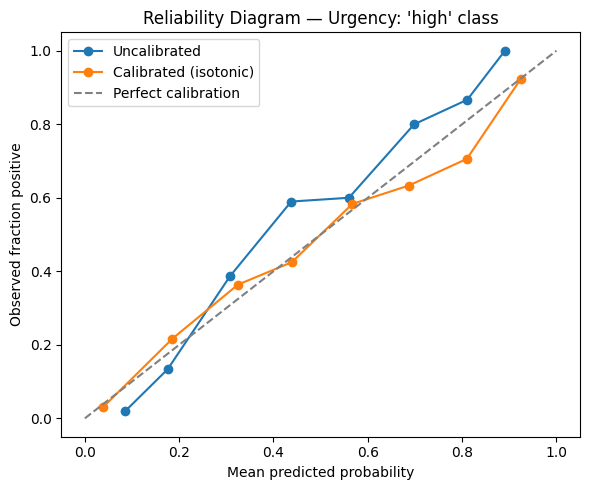

Brier score (uncalibrated): 0.1217
Brier score (calibrated):   0.1152


In [27]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Use "high" urgency as the positive class for a binary reliability view
y2u_test_binary = (y2u_test == "high").astype(int)
uncal_proba_high = urgency_baseline.predict_proba(X2_test_tfidf)[:, list(urgency_baseline.classes_).index("high")]
cal_proba_high = urg_cal_proba[:, list(urgency_calibrated.classes_).index("high")]

fig, ax = plt.subplots(figsize=(6, 5))
for proba, label in [(uncal_proba_high, "Uncalibrated"), (cal_proba_high, "Calibrated (isotonic)")]:
    frac_pos, mean_pred = calibration_curve(y2u_test_binary, proba, n_bins=8)
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Reliability Diagram — Urgency: 'high' class")
ax.legend()
plt.tight_layout()
plt.show()

from sklearn.metrics import brier_score_loss
print(f"Brier score (uncalibrated): {brier_score_loss(y2u_test_binary, uncal_proba_high):.4f}")
print(f"Brier score (calibrated):   {brier_score_loss(y2u_test_binary, cal_proba_high):.4f}")

In [28]:
import numpy as np

# Assumed cost ratio: missing a genuinely "high" urgency doubt (false auto-approval)
# is more costly than an unnecessary teacher review. State assumption explicitly.
COST_FALSE_AUTO_APPROVE = 5   # cost units: an urgent doubt slips through unnoticed
COST_UNNECESSARY_REVIEW = 1   # cost units: teacher spends time on a doubt that didn't need it

# Confidence = max predicted probability across urgency classes (calibrated model)
confidence = urg_cal_proba.max(axis=1)
predicted_class = urgency_calibrated.classes_[np.argmax(urg_cal_proba, axis=1)]
is_correct = (predicted_class == y2u_test.values)

thresholds = np.arange(0.3, 0.96, 0.02)
results = []
for t in thresholds:
    auto_mask = confidence >= t
    coverage = auto_mask.mean()  # fraction auto-approved
    if auto_mask.sum() > 0:
        auto_error_rate = 1 - is_correct[auto_mask].mean()
    else:
        auto_error_rate = 0
    n_auto = auto_mask.sum()
    n_review = (~auto_mask).sum()
    expected_cost = (auto_error_rate * n_auto * COST_FALSE_AUTO_APPROVE) + (n_review * COST_UNNECESSARY_REVIEW)
    results.append({"threshold": t, "coverage": coverage, "auto_error_rate": auto_error_rate,
                     "expected_cost": expected_cost})

threshold_df = pd.DataFrame(results)
best_threshold = threshold_df.loc[threshold_df["expected_cost"].idxmin(), "threshold"]
print(f"Selected threshold: {best_threshold:.2f} (minimizes expected cost under 5:1 cost ratio)")
threshold_df

Selected threshold: 0.90 (minimizes expected cost under 5:1 cost ratio)


,threshold,coverage,auto_error_rate,expected_cost
0,0.30,1.000000,0.375556,845.0
1,0.32,1.000000,0.375556,845.0
2,0.34,1.000000,0.375556,845.0
3,0.36,1.000000,0.375556,845.0
4,0.38,0.995556,0.372768,837.0
5,0.40,0.995556,0.372768,837.0
6,0.42,0.988889,0.373034,835.0
7,0.44,0.975556,0.371298,826.0
8,0.46,0.966667,0.370115,820.0
9,0.48,0.944444,0.364706,800.0


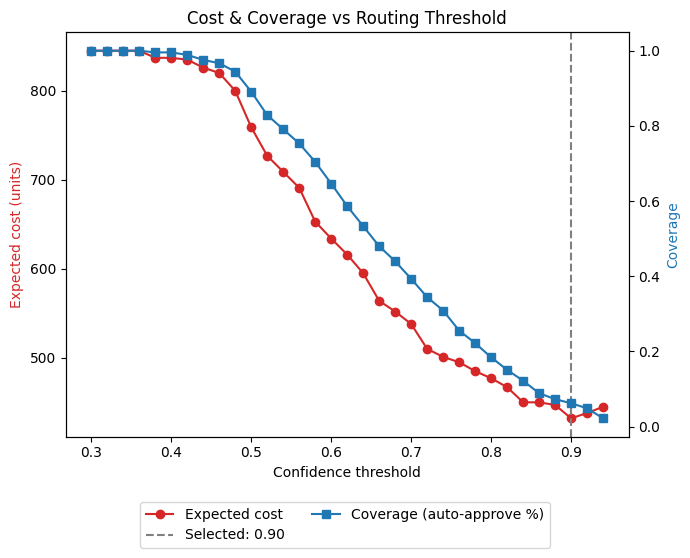

In [29]:
fig, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(threshold_df["threshold"], threshold_df["expected_cost"], color="tab:red", marker="o", label="Expected cost")
ax1.set_xlabel("Confidence threshold")
ax1.set_ylabel("Expected cost (units)", color="tab:red")
ax1.axvline(best_threshold, linestyle="--", color="gray", label=f"Selected: {best_threshold:.2f}")

ax2 = ax1.twinx()
ax2.plot(threshold_df["threshold"], threshold_df["coverage"], color="tab:blue", marker="s", label="Coverage (auto-approve %)")
ax2.set_ylabel("Coverage", color="tab:blue")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0), ncol=2)
plt.title("Cost & Coverage vs Routing Threshold")
plt.tight_layout()
plt.show()

In [30]:
def route_doubt(text, vectorizer, urgency_model, threshold=best_threshold):
    """Returns (predicted_urgency, confidence, routing_decision)."""
    X = vectorizer.transform([text])
    proba = urgency_model.predict_proba(X)[0]
    pred = urgency_model.classes_[np.argmax(proba)]
    conf = proba.max()
    decision = "auto-approve" if conf >= threshold else "teacher review"
    return pred, conf, decision

# quick sanity check
example = X2_test["text"].iloc[0]
print(route_doubt(example, tfidf, urgency_calibrated))

('low', 0.6372930714363996, 'teacher review')


In [31]:
summary = pd.DataFrame({
    "Task": ["Grading (Task 1)", "Grading (Task 1)", "Triage - Topic (Task 2)", "Triage - Urgency (Task 2)"],
    "Model": ["Baseline (LogReg)", "LightGBM", "TF-IDF + LogReg", "TF-IDF + LogReg (calibrated)"],
    "Test F1-macro": [0.929, 0.956, 0.930, 0.631],
    "Notes": ["", "Final model", "", "Below topic-only leakage floor (0.689) — see Leakage Assessment"],
})
summary

,Task,Model,Test F1-macro,Notes
0,Grading (Task 1),Baseline (LogReg),0.929,
1,Grading (Task 1),LightGBM,0.956,Final model
2,Triage - Topic (Task 2),TF-IDF + LogReg,0.930,
3,Triage - Urgency (Task 2),TF-IDF + LogReg (calibrated),0.631,Below topic-only leakage floor (0.689) — see L...


In [32]:
import joblib
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(lgbm, MODELS_DIR / "grading_model.pkl")
joblib.dump(feature_cols, MODELS_DIR / "grading_feature_names.pkl")
joblib.dump(tfidf, MODELS_DIR / "tfidf_vectorizer.pkl")
joblib.dump(urgency_calibrated, MODELS_DIR / "urgency_model.pkl")
joblib.dump({"threshold": best_threshold, "cost_ratio": 5}, MODELS_DIR / "routing_config.pkl")

print("Saved artifacts:", [f.name for f in MODELS_DIR.iterdir()])

Saved artifacts: ['grading_feature_names.pkl', 'grading_model.pkl', 'routing_config.pkl', 'tfidf_vectorizer.pkl', 'urgency_model.pkl']
